# Phase 7 — Explainability and Advanced Model Evaluation

This notebook analyses the frozen final obesity-risk classification model
selected during Phase 6.

The final test set is not used for model selection or hyperparameter tuning.

Phase 7 covers:

1. Final-model verification
2. Global feature importance and SHAP
3. Local prediction explanations
4. Ordinal error analysis
5. BMI feature ablation
6. Subgroup performance analysis

In [1]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

RANDOM_STATE = 42

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.8.0


In [2]:
current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path

while not (
    PROJECT_ROOT / "src" / "preprocessing.py"
).exists():

    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate project root"
        )

    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

In [4]:
from src.preprocessing import (
    NOMINAL_FEATURES,
    NUMERICAL_FEATURES,
    ORDINAL_CATEGORY_ORDERS,
    ORDINAL_FEATURES,
    PREDICTIVE_FEATURES,
    build_preprocessor,
)

print("Predictive features:", len(PREDICTIVE_FEATURES))
print(PREDICTIVE_FEATURES)

Predictive features: 16
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']


In [5]:
DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

FINAL_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "obesity_risk_pipeline.joblib"
)

MODEL_METADATA_PATH = (
    PROJECT_ROOT
    / "models"
    / "model_metadata.json"
)

REPORT_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "generated"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

print("Dataset exists:", DATASET_PATH.exists())
print("Model exists:", FINAL_MODEL_PATH.exists())
print("Metadata exists:", MODEL_METADATA_PATH.exists())

Dataset exists: True
Model exists: True
Metadata exists: True


In [6]:
with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    model_metadata = json.load(file)

saved_sklearn_version = (
    model_metadata["scikit_learn_version"]
)

current_sklearn_version = (
    sklearn.__version__
)

print(
    "Current scikit-learn:",
    current_sklearn_version,
)

print(
    "Saved model scikit-learn:",
    saved_sklearn_version,
)

assert (
    current_sklearn_version
    == saved_sklearn_version
), (
    "scikit-learn version mismatch. "
    f"Current={current_sklearn_version}, "
    f"Saved={saved_sklearn_version}"
)

print("Environment version verified")

Current scikit-learn: 1.8.0
Saved model scikit-learn: 1.8.0
Environment version verified


In [7]:
final_model = joblib.load(
    FINAL_MODEL_PATH
)

print(
    "Loaded model:",
    type(final_model).__name__,
)

assert isinstance(
    final_model,
    Pipeline,
)

print(final_model.named_steps.keys())

Loaded model: Pipeline
dict_keys(['preprocessor', 'classifier'])


In [8]:
final_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

final_classifier = (
    final_model.named_steps[
        "classifier"
    ]
)

transformed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

model_classes = list(
    final_classifier.classes_
)

print(
    "Preprocessor:",
    type(final_preprocessor).__name__,
)

print(
    "Classifier:",
    type(final_classifier).__name__,
)

print(
    "Raw features:",
    len(PREDICTIVE_FEATURES),
)

print(
    "Transformed features:",
    len(transformed_feature_names),
)

print(
    "Classes:",
    len(model_classes),
)

Preprocessor: ColumnTransformer
Classifier: GradientBoostingClassifier
Raw features: 16
Transformed features: 25
Classes: 7


In [9]:
assert len(PREDICTIVE_FEATURES) == 16
assert len(transformed_feature_names) == 25
assert len(model_classes) == 7

assert (
    list(PREDICTIVE_FEATURES)
    == model_metadata[
        "predictive_features"
    ]
)

assert (
    set(model_classes)
    == set(
        model_metadata[
            "target_classes"
        ]
    )
)

print(
    "Model configuration verified"
)

Model configuration verified


In [10]:
dataset = pd.read_csv(
    DATASET_PATH
)

print("Dataset shape:", dataset.shape)

dataset.head()

Dataset shape: (20758, 18)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
TARGET_COLUMN = "NObeyesdad"

X = dataset[
    list(PREDICTIVE_FEATURES)
].copy()

y = dataset[
    TARGET_COLUMN
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20758, 16)
y shape: (20758,)


In [12]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)

(
    X_validation,
    X_test,
    y_validation,
    y_test,
) = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(
    "Training:",
    len(X_train),
)

print(
    "Validation:",
    len(X_validation),
)

print(
    "Test:",
    len(X_test),
)

Training: 14530
Validation: 3114
Test: 3114


In [13]:
assert (
    len(
        X_train.index.intersection(
            X_validation.index
        )
    )
    == 0
)

assert (
    len(
        X_train.index.intersection(
            X_test.index
        )
    )
    == 0
)

assert (
    len(
        X_validation.index.intersection(
            X_test.index
        )
    )
    == 0
)

print("Dataset split verified")

Dataset split verified


In [14]:
phase7_test_predictions = (
    final_model.predict(
        X_test
    )
)

phase7_test_probabilities = (
    final_model.predict_proba(
        X_test
    )
)

print(
    "Predictions:",
    phase7_test_predictions.shape,
)

print(
    "Probabilities:",
    phase7_test_probabilities.shape,
)

Predictions: (3114,)
Probabilities: (3114, 7)


In [15]:
phase7_metrics = {
    "Accuracy":
        accuracy_score(
            y_test,
            phase7_test_predictions,
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_test,
            phase7_test_predictions,
        ),

    "Macro F1":
        f1_score(
            y_test,
            phase7_test_predictions,
            average="macro",
        ),

    "Weighted F1":
        f1_score(
            y_test,
            phase7_test_predictions,
            average="weighted",
        ),
}

phase7_metrics_df = pd.DataFrame(
    phase7_metrics.items(),
    columns=[
        "Metric",
        "Score",
    ],
)

phase7_metrics_df

,Metric,Score
0,Accuracy,0.907514
1,Balanced Accuracy,0.897642
2,Macro F1,0.897328
3,Weighted F1,0.907214


In [16]:
metric_checks = {
    "Accuracy":
        model_metadata[
            "final_test_accuracy"
        ],

    "Balanced Accuracy":
        model_metadata[
            "final_test_balanced_accuracy"
        ],

    "Macro F1":
        model_metadata[
            "final_test_macro_f1"
        ],

    "Weighted F1":
        model_metadata[
            "final_test_weighted_f1"
        ],
}

for metric_name, expected_value in (
    metric_checks.items()
):

    calculated_value = (
        phase7_metrics[
            metric_name
        ]
    )

    assert np.isclose(
        calculated_value,
        expected_value,
        atol=1e-10,
    )

print(
    "Final test metrics match metadata"
)

Final test metrics match metadata


In [17]:
test_analysis_df = (
    X_test.copy()
)

test_analysis_df[
    "True_Class"
] = y_test

test_analysis_df[
    "Predicted_Class"
] = phase7_test_predictions

test_analysis_df[
    "Correct_Prediction"
] = (
    test_analysis_df[
        "True_Class"
    ]
    == test_analysis_df[
        "Predicted_Class"
    ]
)

test_analysis_df[
    "Prediction_Confidence"
] = (
    phase7_test_probabilities.max(
        axis=1
    )
)

test_analysis_df[
    [
        "True_Class",
        "Predicted_Class",
        "Correct_Prediction",
        "Prediction_Confidence",
    ]
].head()

,True_Class,Predicted_Class,Correct_Prediction,Prediction_Confidence
16056,Obesity_Type_III,Obesity_Type_III,True,0.999160
19997,Obesity_Type_II,Obesity_Type_II,True,0.996750
16512,Insufficient_Weight,Normal_Weight,False,0.763893
344,Obesity_Type_I,Obesity_Type_II,False,0.990206
6633,Insufficient_Weight,Insufficient_Weight,True,0.879578


In [18]:
assert len(test_analysis_df) == 3114
assert final_model is not None
assert final_preprocessor is not None
assert final_classifier is not None

print(
    "Validation passed"
)

Validation passed


In [19]:
import shap

required_variables = [
    "final_model",
    "final_preprocessor",
    "final_classifier",
    "transformed_feature_names",
    "model_classes",
    "X_train",
    "X_validation",
    "X_test",
    "y_test",
    "test_analysis_df",
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

assert not missing_variables, (
    "Checkpoint 1 must be executed first. "
    f"Missing: {missing_variables}"
)

print("SHAP:", shap.__version__)
print(
    "Checkpoint 2 dependencies verified"
)

SHAP: 0.52.0
Checkpoint 2 dependencies verified


c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
tree_feature_importance_df = (
    pd.DataFrame(
        {
            "Transformed_Feature":
                transformed_feature_names,

            "Importance":
                final_classifier
                .feature_importances_,
        }
    )
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

tree_feature_importance_df.head(15)

,Transformed_Feature,Importance
0,numerical__Weight,0.580780
1,numerical__FCVC,0.100567
2,numerical__Height,0.076616
3,nominal__Gender_Male,0.055070
4,nominal__Gender_Female,0.051784
5,numerical__Age,0.039661
6,numerical__TUE,0.025355
7,numerical__CH2O,0.015359
8,numerical__NCP,0.014888
9,ordinal__CALC,0.013725


In [21]:
def get_raw_feature_name(
    transformed_feature_name,
):
    clean_name = (
        transformed_feature_name
        .split("__", 1)[-1]
    )

    for raw_feature in sorted(
        PREDICTIVE_FEATURES,
        key=len,
        reverse=True,
    ):

        if (
            clean_name == raw_feature
            or clean_name.startswith(
                f"{raw_feature}_"
            )
        ):
            return raw_feature

    return clean_name

In [22]:
tree_feature_importance_df[
    "Raw_Feature"
] = (
    tree_feature_importance_df[
        "Transformed_Feature"
    ]
    .apply(
        get_raw_feature_name
    )
)

raw_tree_importance_df = (
    tree_feature_importance_df
    .groupby(
        "Raw_Feature",
        as_index=False,
    )["Importance"]
    .sum()
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_tree_importance_df

,Raw_Feature,Importance
0,Weight,0.580780
1,Gender,0.106854
2,FCVC,0.100567
3,Height,0.076616
4,Age,0.039661
5,TUE,0.025355
6,CH2O,0.015359
7,NCP,0.014888
8,CALC,0.013725
9,CAEC,0.008694


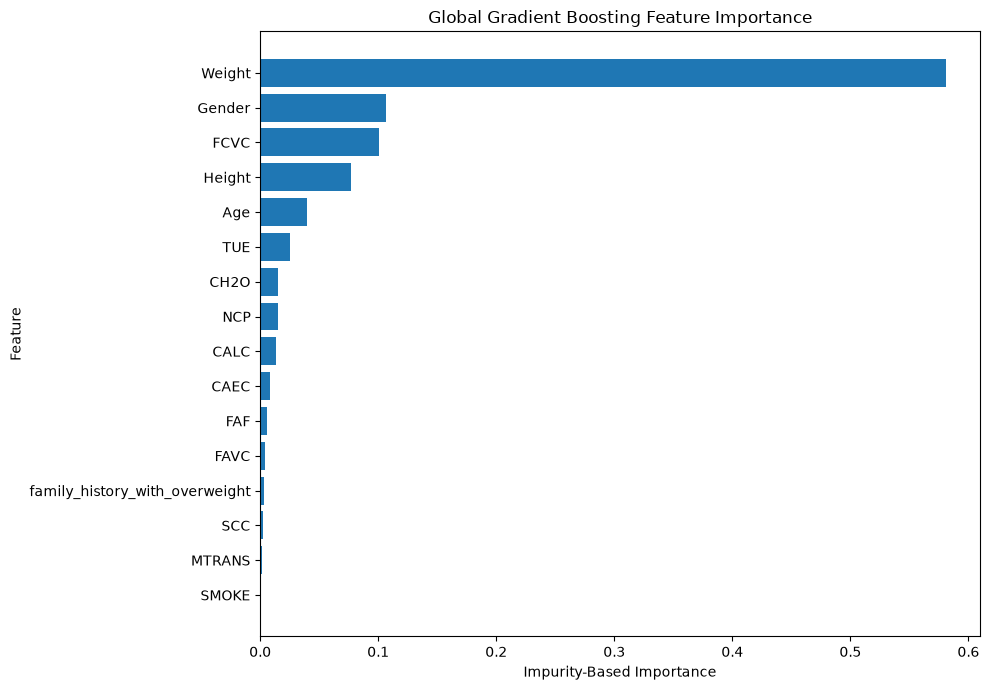

In [23]:
plt.figure(
    figsize=(10, 7)
)

plot_data = (
    raw_tree_importance_df
    .sort_values(
        "Importance",
        ascending=True,
    )
)

plt.barh(
    plot_data["Raw_Feature"],
    plot_data["Importance"],
)

plt.xlabel(
    "Impurity-Based Importance"
)

plt.ylabel("Feature")

plt.title(
    "Global Gradient Boosting "
    "Feature Importance"
)

plt.tight_layout()

tree_figure_path = (
    FIGURE_DIRECTORY
    / "global_tree_feature_importance.png"
)

plt.savefig(
    tree_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [24]:
X_development = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
)

SHAP_BACKGROUND_SIZE = 30
SHAP_SAMPLES_PER_CLASS = 8

X_shap_background_raw = (
    X_development.sample(
        n=SHAP_BACKGROUND_SIZE,
        random_state=RANDOM_STATE,
    )
)

shap_sample_indices = []

for class_name in model_classes:

    class_indices = (
        y_test[
            y_test == class_name
        ]
        .sample(
            n=SHAP_SAMPLES_PER_CLASS,
            random_state=RANDOM_STATE,
        )
        .index
        .tolist()
    )

    shap_sample_indices.extend(
        class_indices
    )

X_shap_raw = (
    X_test
    .loc[
        shap_sample_indices
    ]
    .copy()
)

print(
    "Background:",
    len(X_shap_background_raw),
)

print(
    "Explanation sample:",
    len(X_shap_raw),
)

Background: 30
Explanation sample: 56


In [25]:
X_shap_background_transformed = np.asarray(
    final_preprocessor.transform(
        X_shap_background_raw
    )
)

X_shap_transformed = np.asarray(
    final_preprocessor.transform(
        X_shap_raw
    )
)

print(
    "Background shape:",
    X_shap_background_transformed.shape,
)

print(
    "SHAP sample shape:",
    X_shap_transformed.shape,
)

assert (
    X_shap_background_transformed.shape[1]
    == len(transformed_feature_names)
)

assert (
    X_shap_transformed.shape[1]
    == len(transformed_feature_names)
)

print(
    "SHAP transformed data verified"
)

Background shape: (30, 25)
SHAP sample shape: (56, 25)
SHAP transformed data verified


In [26]:
def shap_predict_proba(data):
    return final_classifier.predict_proba(
        np.asarray(data)
    )


shap_explainer = shap.Explainer(
    shap_predict_proba,
    X_shap_background_transformed,
    algorithm="permutation",
    feature_names=list(
        transformed_feature_names
    ),
    output_names=model_classes,
    seed=RANDOM_STATE,
)

print(
    "Explainer:",
    type(shap_explainer).__name__,
)

Explainer: PermutationExplainer


In [27]:
SHAP_MAX_EVALS = (
    2 * len(transformed_feature_names)
    + 1
)

print(
    "Max evaluations:",
    SHAP_MAX_EVALS,
)

shap_values = shap_explainer(
    X_shap_transformed,
    max_evals=SHAP_MAX_EVALS,
)

shap_array = np.asarray(
    shap_values.values
)

print(
    "SHAP shape:",
    shap_array.shape,
)

Max evaluations: 51
SHAP shape: (56, 25, 7)


In [28]:
if (
    shap_array.ndim == 3
    and shap_array.shape[1]
    != len(transformed_feature_names)
    and shap_array.shape[2]
    == len(transformed_feature_names)
):
    shap_array = np.transpose(
        shap_array,
        (0, 2, 1),
    )

assert shap_array.ndim == 3

assert (
    shap_array.shape[1]
    == len(transformed_feature_names)
)

assert (
    shap_array.shape[2]
    == len(model_classes)
)

print(
    "Normalized SHAP shape:",
    shap_array.shape,
)

Normalized SHAP shape: (56, 25, 7)


In [29]:
global_shap_importance = (
    np.abs(shap_array)
    .mean(axis=(0, 2))
)

shap_feature_importance_df = pd.DataFrame(
    {
        "Transformed_Feature":
            transformed_feature_names,

        "SHAP_Importance":
            global_shap_importance,
    }
)

shap_feature_importance_df[
    "Raw_Feature"
] = (
    shap_feature_importance_df[
        "Transformed_Feature"
    ]
    .apply(get_raw_feature_name)
)

raw_shap_importance_df = (
    shap_feature_importance_df
    .groupby(
        "Raw_Feature",
        as_index=False,
    )["SHAP_Importance"]
    .sum()
    .sort_values(
        "SHAP_Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_shap_importance_df

,Raw_Feature,SHAP_Importance
0,Weight,0.165339
1,FCVC,0.039528
2,Height,0.037055
3,Gender,0.029054
4,Age,0.020786
5,CH2O,0.011997
6,TUE,0.011963
7,MTRANS,0.009090
8,CALC,0.007804
9,family_history_with_overweight,0.007601


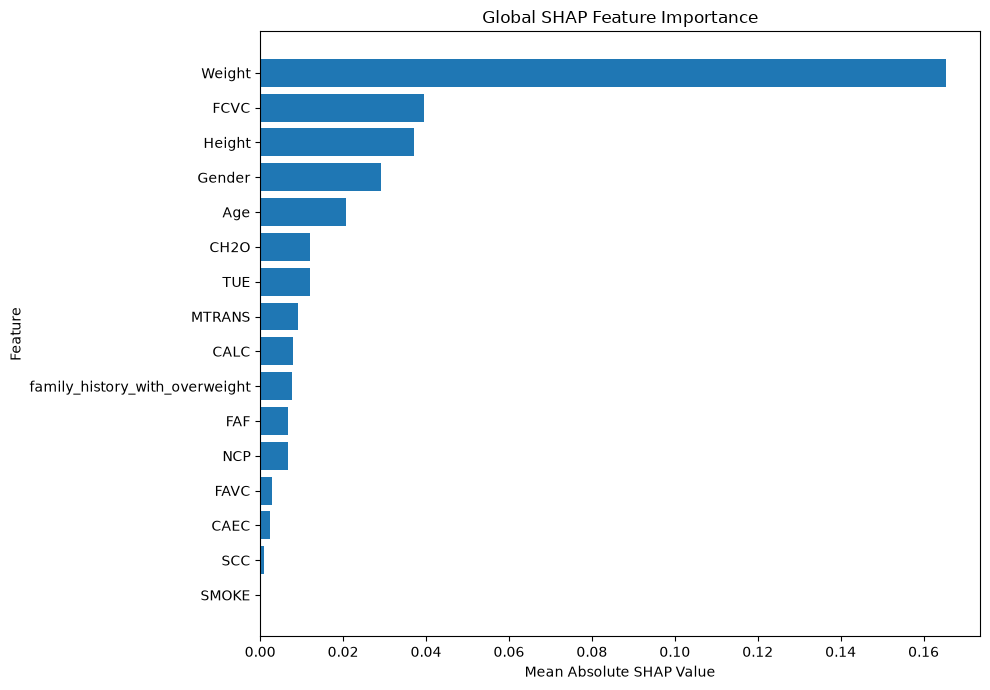

Saved: C:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\reports\figures\global_shap_feature_importance.png


In [30]:
plt.figure(
    figsize=(10, 7)
)

plot_data = (
    raw_shap_importance_df
    .sort_values(
        "SHAP_Importance",
        ascending=True,
    )
)

plt.barh(
    plot_data["Raw_Feature"],
    plot_data["SHAP_Importance"],
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

shap_figure_path = (
    FIGURE_DIRECTORY
    / "global_shap_feature_importance.png"
)

plt.savefig(
    shap_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    shap_figure_path,
)

In [31]:
importance_comparison_df = (
    raw_tree_importance_df
    .rename(
        columns={
            "Importance":
                "Tree_Importance"
        }
    )
    .merge(
        raw_shap_importance_df,
        on="Raw_Feature",
        how="inner",
    )
)

importance_comparison_df[
    "Tree_Rank"
] = (
    importance_comparison_df[
        "Tree_Importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_df[
    "SHAP_Rank"
] = (
    importance_comparison_df[
        "SHAP_Importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_df = (
    importance_comparison_df
    .sort_values(
        "SHAP_Rank"
    )
    .reset_index(drop=True)
)

importance_comparison_df

,Raw_Feature,Tree_Importance,SHAP_Importance,Tree_Rank,SHAP_Rank
0,Weight,0.580780,0.165339,1,1
1,FCVC,0.100567,0.039528,3,2
2,Height,0.076616,0.037055,4,3
3,Gender,0.106854,0.029054,2,4
4,Age,0.039661,0.020786,5,5
5,CH2O,0.015359,0.011997,7,6
6,TUE,0.025355,0.011963,6,7
7,MTRANS,0.001880,0.009090,15,8
8,CALC,0.013725,0.007804,9,9
9,family_history_with_overweight,0.003256,0.007601,13,10


In [32]:
tree_report_path = (
    REPORT_DIRECTORY
    / "global_tree_feature_importance.csv"
)

shap_report_path = (
    REPORT_DIRECTORY
    / "global_shap_feature_importance.csv"
)

importance_comparison_path = (
    REPORT_DIRECTORY
    / "global_feature_importance_comparison.csv"
)

raw_tree_importance_df.to_csv(
    tree_report_path,
    index=False,
)

raw_shap_importance_df.to_csv(
    shap_report_path,
    index=False,
)

importance_comparison_df.to_csv(
    importance_comparison_path,
    index=False,
)

print(
    "Checkpoint 2 reports saved"
)

Checkpoint 2 reports saved


In [33]:
assert len(
    raw_tree_importance_df
) == 16

assert len(
    raw_shap_importance_df
) == 16

assert tree_figure_path.exists()
assert shap_figure_path.exists()

assert tree_report_path.exists()
assert shap_report_path.exists()
assert importance_comparison_path.exists()

print(
    "Validation passed"
)

Validation passed
